# 勇者傳說 — Monster V2 Generator (T4 GPU)

Generate new monster sprites using **SDXL + pixel-art-xl LoRA** on Colab T4.

| Category | Count | Size | Steps | Guidance |
|----------|-------|------|-------|----------|
| Bosses | 3 | 256px | 28 | 8.0 |
| Base Monsters | 20 | 192px | 22 | 7.0 |
| Variants | 20 | 192px | 20 | 7.0 |
| **Total** | **43** | | | |

**Self-contained**: No repo clone needed — all code + prompts embedded in this notebook.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/`  
**Resume**: 中斷後重跑自動跳過已完成的

## 1. Setup

In [1]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, os, time
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    DEVICE = 'cuda'
    DTYPE = torch.float16
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU! Generation will be very slow.')

print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [2]:
class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')

## 3. Prompt Data

In [3]:
PROMPTS = {
    "_meta": {
        "style_prefix_xl": "16-bit JRPG pixel art, Dragonquest style",
        "style_suffix_monster_xl": "single creature centered, dark background, clean edges, detailed sprite",
        "negative_prompt_xl": "blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, human, realistic photo"
    },
    "bosses": [
        {"name": "mon_boss_volcano_lord", "prompt_xl": "massive volcanic fire lord boss monster, magma armor dripping lava, glowing orange eyes, molten rock body, erupting flames from shoulders, imposing dark figure", "size": 256, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "mon_boss_hotspring_guardian", "prompt_xl": "ancient water spirit guardian boss, crystalline aqua body, steam clouds, serene powerful expression, jade and turquoise armor, flowing water tendrils", "size": 256, "steps_xl": 28, "guidance_xl": 8.0},
        {"name": "mon_boss_ice_king", "prompt_xl": "towering ice king boss monster, frozen crown of icicles, pale blue crystalline armor, frost breath, glacial cape, commanding blizzard aura", "size": 256, "steps_xl": 28, "guidance_xl": 8.0},
    ],
    "base_monsters": [
        {"name": "mon_elemental", "prompt_xl": "swirling elemental orb creature, energy vortex of fire wind and water, glowing core, floating magical sphere with arcane runes", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_bird", "prompt_xl": "fierce raptor eagle monster, sharp talons and beak, spread wings, aggressive hunting bird with armored feathers", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_bear", "prompt_xl": "massive dire bear monster, thick dark fur, sharp claws, muscular stance, scarred battle-hardened grizzly", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_turtle", "prompt_xl": "armored giant tortoise monster, spiked shell with mossy runes, ancient wise eyes, heavy defensive stance", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_crab", "prompt_xl": "giant pincer crab monster, armored carapace, huge crushing claws, barnacle-covered shell, ocean creature", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_insect", "prompt_xl": "large armored beetle monster, iridescent shell, sharp mandibles, segmented body, chitinous legs", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_demon", "prompt_xl": "fierce demon monster, red skin, curved horns, bat wings, muscular torso, demonic fire in hands", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_plant", "prompt_xl": "carnivorous plant monster, venus flytrap head with fangs, thorny vines, bulbous poison sac body", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_lizard", "prompt_xl": "fire lizard monster, scaled red body, flame tail, reptilian eyes, sharp claws, breathing embers", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_zombie", "prompt_xl": "shambling undead zombie monster, rotting flesh, exposed bones, tattered clothing, glowing eyes, reaching arms", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_mage", "prompt_xl": "evil sorcerer monster, dark robes with glowing runes, floating grimoire, arcane energy orbs, sinister hood", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_knight", "prompt_xl": "corrupted dark knight monster, dented black armor, tattered red cape, cursed glowing sword, undead warrior", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_worm", "prompt_xl": "giant worm centipede monster, segmented armored body, many legs, poison mandibles, burrowing out of ground", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_rat", "prompt_xl": "plague rat monster, oversized mutant rodent, matted fur, glowing red eyes, sharp yellow teeth, diseased", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_octopus", "prompt_xl": "tentacle octopus monster, writhing purple tentacles, bulbous head, bioluminescent spots, deep sea horror", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_snowman", "prompt_xl": "ice yeti snowman monster, frozen fur, icicle claws, frost breath, pale blue skin, mountain beast", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_golem_fire", "prompt_xl": "molten lava golem monster, cracked obsidian body with glowing magma veins, burning fists, volcanic core", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_puppet", "prompt_xl": "mechanical automaton puppet monster, wooden body with gears, glowing eyes, marionette strings, clockwork joints", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_angel_dark", "prompt_xl": "fallen angel monster, tattered black wings, corrupted halo, pale skin, dark energy aura, broken armor", "size": 192, "steps_xl": 22, "guidance_xl": 7.0},
        {"name": "mon_phantom", "prompt_xl": "dark chaos phantom monster, swirling shadow form, glowing red eyes, ethereal body dissolving into smoke", "size": 192, "steps_xl": 22, "guidance_xl": 7.0}
    ],
    "variants": [
        {"name": "mon_slime_forest", "prompt_xl": "forest slime creature, green translucent gel body with leaves and twigs inside, mossy, nature spirit", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_slime_ocean", "prompt_xl": "ocean water slime creature, blue translucent gel body with bubbles and small fish inside, aquatic", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_slime_ice", "prompt_xl": "ice slime creature, pale crystalline frozen gel body with frost patterns and icicles, cold aura", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_slime_lava", "prompt_xl": "lava slime creature, molten red-orange gel body with flame wisps and obsidian chunks, burning", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_slime_metal", "prompt_xl": "metal slime creature, shiny silver mercury-like liquid body, reflective surface, rare metallic gleam", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_slime_swamp", "prompt_xl": "swamp slime creature, murky brown-green toxic gel body with mushrooms growing on it, fetid bubbles", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_wolf_dire", "prompt_xl": "dire wolf beast, massive dark gray wolf with glowing amber eyes, scarred muzzle, alpha predator", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_wolf_ice", "prompt_xl": "ice wolf beast, white fur with frost crystals, pale blue eyes, breath of cold mist, arctic hunter", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_spider_cave", "prompt_xl": "cave spider monster, dark hairy spider with glowing eyes, web silk trailing, stalactite dwelling", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_bat_vampire", "prompt_xl": "vampire bat monster, large winged bat with red eyes and fangs, dark membrane wings, bloodthirsty", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_skeleton_archer", "prompt_xl": "skeleton archer undead, bone warrior with bow and arrow, tattered hood, glowing eye sockets", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_skeleton_mage", "prompt_xl": "skeleton mage undead, robed bone sorcerer with glowing staff, arcane symbols floating around skull", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_ghost_wraith", "prompt_xl": "wraith ghost monster, dark hooded spectral figure, trailing shadow robes, ice-cold blue ghostly hands", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_dragon_ice", "prompt_xl": "ice dragon, white-blue scales with frost crystals, frozen breath, icicle horns, glacial wings", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_dragon_bone", "prompt_xl": "bone dragon undead, skeletal dragon with tattered wing membranes, glowing eye sockets, necrotic aura", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_goblin_thief", "prompt_xl": "goblin thief rogue, hooded small green creature with dagger, coin pouch, sneaky expression", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_golem_crystal", "prompt_xl": "crystal golem monster, body of purple and blue crystals, prismatic light refractions, gem core", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_scorpion_desert", "prompt_xl": "desert scorpion monster, sandy brown armored scorpion, venomous tail raised, large pincers", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_flower_mushroom", "prompt_xl": "mushroom monster, large spotted toadstool with face, spore cloud, stubby legs, forest fungus creature", "size": 192, "steps_xl": 20, "guidance_xl": 7.0},
        {"name": "mon_coral", "prompt_xl": "coral reef monster, living coral formation with eyes and mouth, tentacle polyps, ocean creature", "size": 192, "steps_xl": 20, "guidance_xl": 7.0}
    ]
}

## 4. Load SDXL Pipeline + LoRA

In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if 'stabilityai' in model_path:
    kwargs['variant'] = 'fp16'

pipe = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe.set_adapters(['pixel_xl'], adapter_weights=[0.8])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.8)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

# Cache to Drive for future runs
if 'stabilityai' in model_path and ON_COLAB:
    try:
        pipe.save_pretrained(str(sdxl_cache))
        print(f'[pipeline] Cached to {sdxl_cache}')
    except Exception:
        pass

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.8)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[pipeline] Cached to /content/drive/MyDrive/ai-rpg-game/models/stable-diffusion-xl-base-1.0
[pipeline] Ready in 379.6s
[vram] 6.7/14.6 GB


## 5. Background Removal + Post-Processing

In [5]:
from PIL import Image
import numpy as np

_rembg_session = None

def remove_background(img):
    """Remove background using rembg."""
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(img, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return img


def build_prompt(entry, meta, category):
    """Build full prompt and negative prompt for an entry."""
    prefix = meta.get('style_prefix_xl', '')
    suffix = meta.get('style_suffix_monster_xl', '')
    neg = meta.get('negative_prompt_xl', '')
    prompt_body = entry.get('prompt_xl', '')
    prompt = f'{prefix}, {prompt_body}, {suffix}'
    return prompt, neg


def postprocess(img, entry, category):
    """Remove background, crop, resize to target size with bottom-align."""
    target_size = entry.get('size', 192)

    # Remove background
    img = remove_background(img.convert('RGBA'))

    # Crop to content bounding box
    arr = np.array(img)
    alpha = arr[:, :, 3]
    rows = np.any(alpha > 10, axis=1)
    cols = np.any(alpha > 10, axis=0)
    if not rows.any():
        return img.resize((target_size, target_size), Image.NEAREST)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = img.crop((cmin, rmin, cmax + 1, rmax + 1))

    # Scale to fit target size (maintain aspect ratio)
    cw, ch = cropped.size
    scale = min(target_size / cw, target_size / ch)
    new_w = max(1, int(cw * scale))
    new_h = max(1, int(ch * scale))
    resized = cropped.resize((new_w, new_h), Image.NEAREST)

    # Center horizontally, bottom-align vertically on transparent canvas
    canvas = Image.new('RGBA', (target_size, target_size), (0, 0, 0, 0))
    x = (target_size - new_w) // 2
    y = target_size - new_h
    canvas.paste(resized, (x, y))
    return canvas


def generate_one(entry, meta, category, out_dir, tracker):
    """Generate a single sprite: prompt -> SDXL -> postprocess -> save."""
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [skip] {name}')
        return

    prompt, neg = build_prompt(entry, meta, category)
    steps = entry.get('steps_xl', 22)
    guidance = entry.get('guidance_xl', 7.0)
    target_size = entry.get('size', 192)

    print(f'  {name} ({target_size}px, {steps} steps)...', end=' ')
    t0 = time.time()

    result = pipe(
        prompt=prompt, negative_prompt=neg,
        width=512, height=512,
        num_inference_steps=steps,
        guidance_scale=guidance,
    )
    img = postprocess(result.images[0], entry, category)
    img.save(str(out_path), 'PNG')

    kb = out_path.stat().st_size / 1024
    print(f'{kb:.0f} KB, {time.time()-t0:.1f}s')
    tracker.mark_done(name)
    free_vram()

## 6. Test: Generate 1 Sprite

Prompt: 16-bit JRPG pixel art, Dragonquest style, massive volcanic fire lord boss monster, magma armor dripp...
Negative: blurry, text, watermark, signature, duplicate, pair, group, multiple creatures, ...


  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


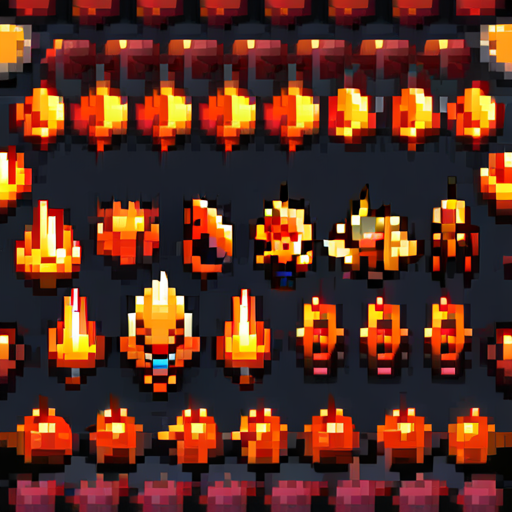

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

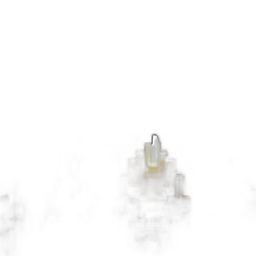

In [6]:
from IPython.display import display

meta = PROMPTS['_meta']
test_entry = PROMPTS['bosses'][0]
prompt, neg = build_prompt(test_entry, meta, 'monsters')
print(f'Prompt: {prompt[:100]}...')
print(f'Negative: {neg[:80]}...')

result = pipe(prompt=prompt, negative_prompt=neg, width=512, height=512,
              num_inference_steps=test_entry.get('steps_xl', 28),
              guidance_scale=test_entry.get('guidance_xl', 8.0))
display(result.images[0])
test_img = postprocess(result.images[0], test_entry, 'monsters')
display(test_img)
free_vram()

## 7. Generate Bosses (3 sprites)

~8s per boss on T4

In [7]:
entries = PROMPTS['bosses']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'monsters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('monsters_v2_bosses', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nBosses: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'monsters', out_dir, tracker)

print(f'\nDone!')


Bosses: 3 total, 3 to generate

[1/3] 0/3 done
  mon_boss_volcano_lord (256px, 28 steps)... 

  0%|          | 0/28 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


67 KB, 14.5s

[2/3] 1/3 done, ~1 min remaining
  mon_boss_hotspring_guardian (256px, 28 steps)... 

  0%|          | 0/28 [00:00<?, ?it/s]

74 KB, 13.9s

[3/3] 2/3 done, ~0 min remaining
  mon_boss_ice_king (256px, 28 steps)... 

  0%|          | 0/28 [00:00<?, ?it/s]

52 KB, 14.5s

Done!


## 8. Generate Base Monsters (20 sprites)

~5-7s per sprite on T4

In [8]:
entries = PROMPTS['base_monsters']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'monsters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('monsters_v2_base', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nBase Monsters: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'monsters', out_dir, tracker)

print(f'\nDone!')


Base Monsters: 20 total, 20 to generate

[1/20] 0/20 done
  mon_elemental (192px, 22 steps)... 

  0%|          | 0/22 [00:00<?, ?it/s]

36 KB, 11.4s

[2/20] 1/20 done, ~4 min remaining
  mon_bird (192px, 22 steps)... 

  0%|          | 0/22 [00:00<?, ?it/s]

22 KB, 12.1s

[3/20] 2/20 done, ~4 min remaining
  mon_bear (192px, 22 steps)... 

...

17 KB, 10.0s

[19/20] 18/20 done, ~0 min remaining
  mon_angel_dark (192px, 22 steps)... 

  0%|          | 0/22 [00:00<?, ?it/s]

30 KB, 9.9s

[20/20] 19/20 done, ~0 min remaining
  mon_phantom (192px, 22 steps)... 

  0%|          | 0/22 [00:00<?, ?it/s]

41 KB, 10.2s

Done!


## 9. Generate Variants (20 sprites)

~4-6s per sprite on T4

In [9]:
entries = PROMPTS['variants']
meta = PROMPTS['_meta']
out_dir = OUTPUT_BASE / 'monsters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('monsters_v2_variants', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'\nVariants: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    print(f'\n[{i+1}/{len(entries)}] {tracker.summary(len(entries))}')
    generate_one(entry, meta, 'monsters', out_dir, tracker)

print(f'\nDone!')


Variants: 20 total, 20 to generate

[1/20] 0/20 done
  mon_slime_forest (192px, 20 steps)... 

  0%|          | 0/20 [00:00<?, ?it/s]

29 KB, 9.5s

[2/20] 1/20 done, ~3 min remaining
  mon_slime_ocean (192px, 20 steps)... 

  0%|          | 0/20 [00:00<?, ?it/s]

44 KB, 8.8s

[3/20] 2/20 done, ~3 min remaining
  mon_slime_ice (192px, 20 steps)... 

...

40 KB, 9.5s

[19/20] 18/20 done, ~0 min remaining
  mon_flower_mushroom (192px, 20 steps)... 

  0%|          | 0/20 [00:00<?, ?it/s]

28 KB, 8.9s

[20/20] 19/20 done, ~0 min remaining
  mon_coral (192px, 20 steps)... 

  0%|          | 0/20 [00:00<?, ?it/s]

26 KB, 9.5s

Done!


## 10. Quality Review

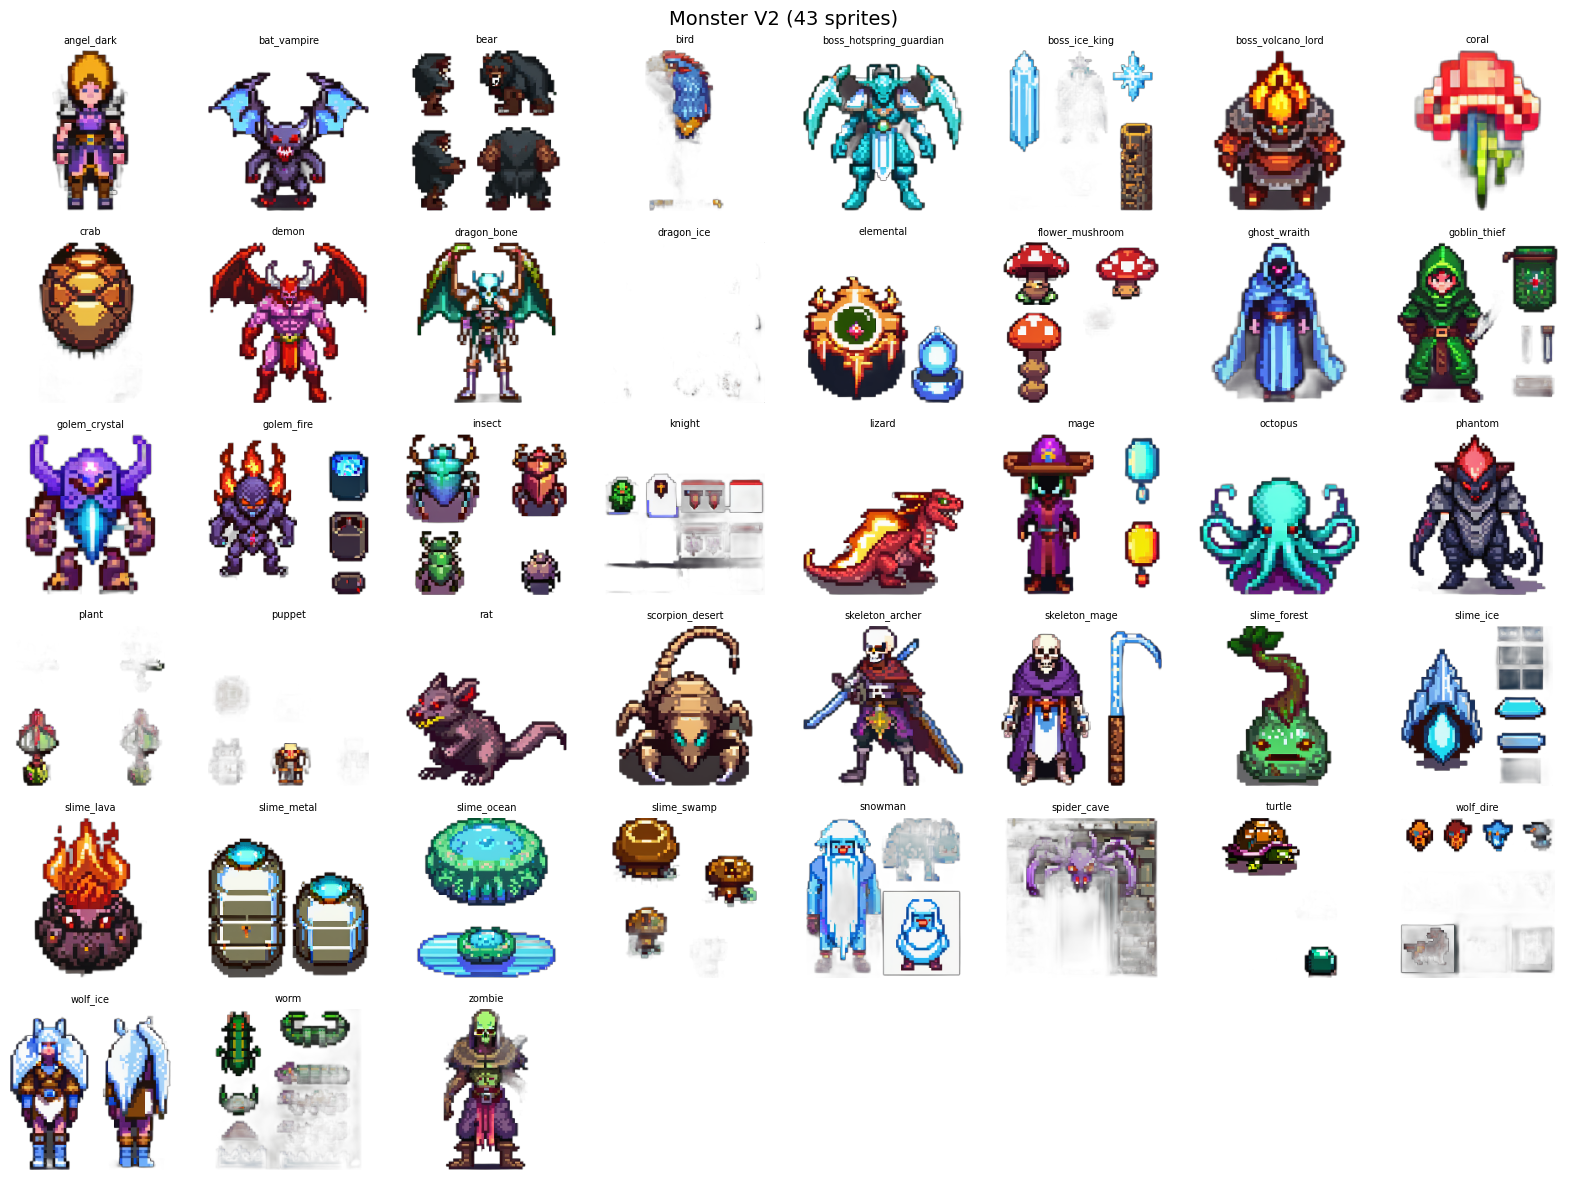

In [ ]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'monsters'
pngs = sorted(out_dir.glob('*.png'))
pngs = [p for p in pngs if not p.stem.startswith('_')]

cols = 8
rows = (len(pngs) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
for ax in axes.flat:
    ax.axis('off')

for i, png in enumerate(pngs):
    ax = axes[i // cols][i % cols] if rows > 1 else axes[i % cols]
    img = Image.open(png)
    ax.imshow(img)
    ax.set_title(png.stem.replace('mon_', ''), fontsize=7)

plt.suptitle(f'Monster V2 ({len(pngs)} sprites)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Generate Manifest + Download

In [ ]:
import shutil

manifest = {}
d = OUTPUT_BASE / 'monsters'
if d.exists():
    keys = sorted(f.stem for f in d.glob('*.png') if not f.stem.startswith('_'))
    if keys:
        manifest['monsters'] = keys

manifest_path = OUTPUT_BASE / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')

zip_path = '/content/monsters_v2_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')